<a href="https://colab.research.google.com/github/elysewong/crmlsanalysis/blob/main/Copy_of_IDX_EXCHANGE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install seaborn


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
# Load the data
df = pd.read_csv("/crmls_last_6_months.csv", low_memory=False)

In [ ]:
# Filter for Residential and SingleFamilyResidence
df = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
]

In [ ]:
#Select relevant columns
features = ['LivingArea', 'BathroomsTotalInteger', 'BedroomsTotal', 'GarageSpaces']
target = 'ClosePrice'

In [ ]:
# Drop rows with missing data
df_model = df[features + [target]].dropna()

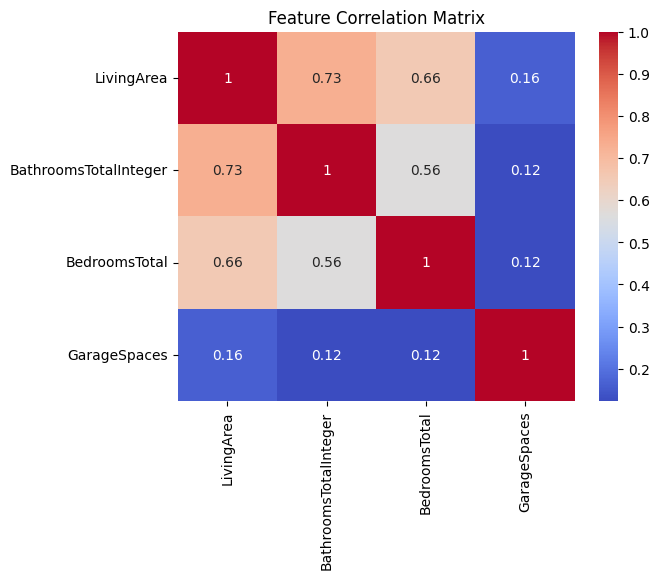

In [ ]:
# Check for multicollinearity
corr_matrix = df_model[features].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
# Split the data
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)


In [ ]:
# Fit the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Evaluate the model
y_pred = model.predict(X_test)
print("R-squared:", round(r2_score(y_test, y_pred), 3))
print("Mean Squared Error:", round(mean_squared_error(y_test, y_pred), 2))

R-squared: 0.391
Mean Squared Error: 792590712735.81


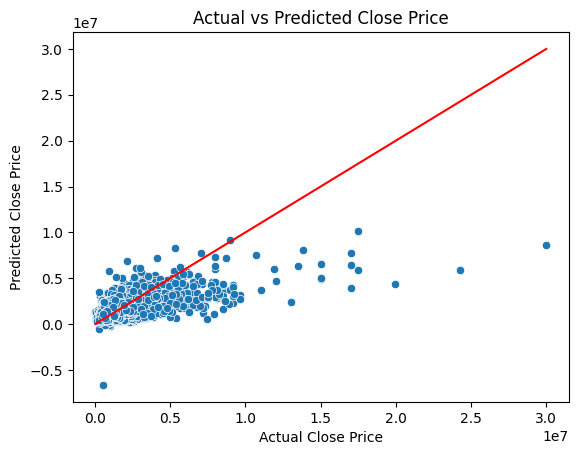

In [ ]:
# Plot predicted vs actual values
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted Close Price")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.show()

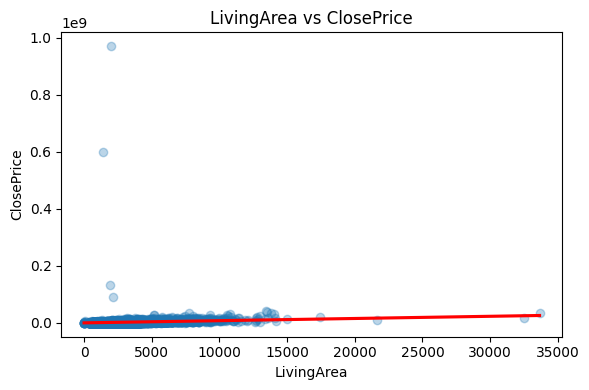

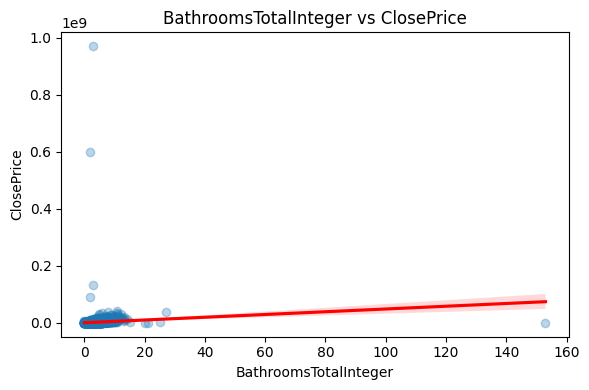

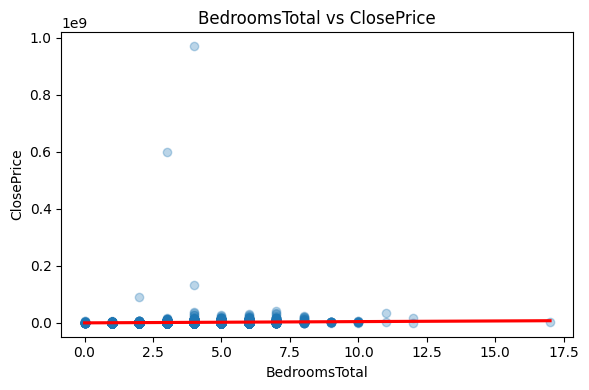

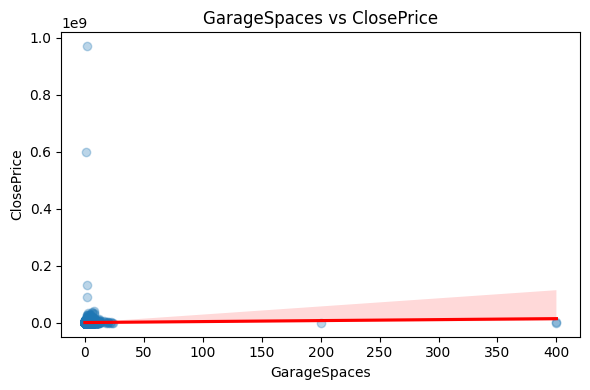

In [ ]:
# List of features analyzing
features = ['LivingArea', 'BathroomsTotalInteger', 'BedroomsTotal', 'GarageSpaces']

# Plot each feature vs ClosePrice with a regression line
for col in features:
    plt.figure(figsize=(6, 4))
    sns.regplot(x=df_model[col], y=df_model['ClosePrice'], scatter_kws={'alpha':0.3}, line_kws={'color': 'red'})
    plt.title(f'{col} vs ClosePrice')
    plt.xlabel(col)
    plt.ylabel('ClosePrice')
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Load the data
df = pd.read_csv("/crmls_last_6_months.csv", low_memory=False)

In [ ]:
# CLEANING
# Drop rows where ClosePrice or LivingArea is missing or 0
df = df[df["LivingArea"].notna() & (df["LivingArea"] > 0)]
df = df[df["ClosePrice"].notna()]

In [ ]:
# Truncate zip codes to 5 digits
df["ZipCode"] = df["PostalCode"].astype(str).str[:5]

In [ ]:
# Select features
features = ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger",
            "GarageSpaces", "ZipCode", "HighSchoolDistrict"]
target = "ClosePrice"

df = df[features + [target]].copy()

In [ ]:
# Drop rows with missing values in selected features
df.dropna(inplace=True)

In [ ]:
# Encode categorical features
le_zip = LabelEncoder()
le_school = LabelEncoder()
df["ZipCode"] = le_zip.fit_transform(df["ZipCode"])
df["HighSchoolDistrict"] = le_school.fit_transform(df["HighSchoolDistrict"])

In [ ]:
# ====== MODELING ======
X = df[features]
y = df[target]

In [ ]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Train Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Predict and evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.3f}")
print(f"Mean Absolute Error: ${mae:,.2f}")

R² Score: 0.120
Mean Absolute Error: $434,328.74


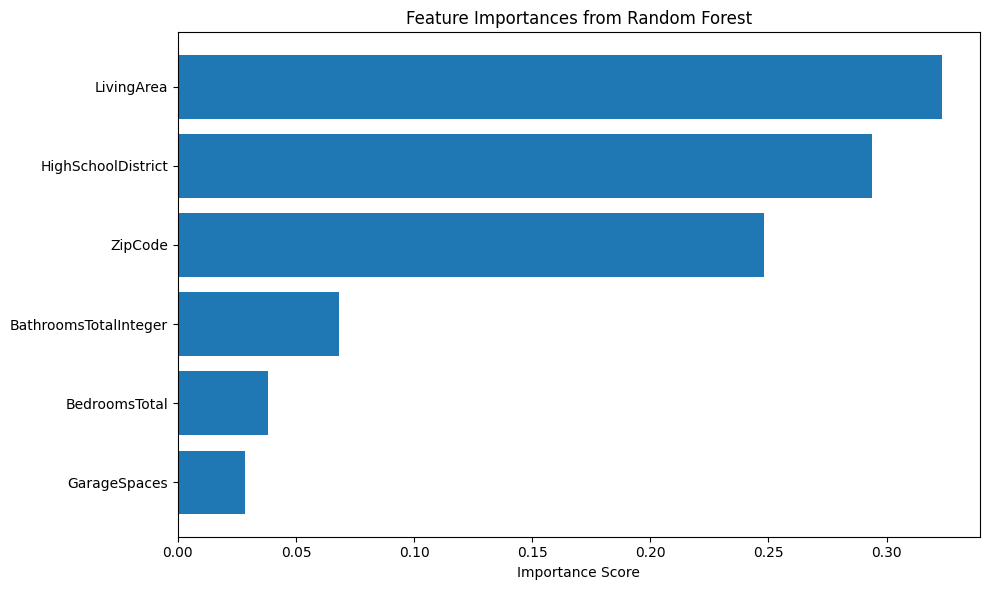

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance plot
importances = model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({"Feature": features, "Importance": importances})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importances from Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [ ]:
df[["StateOrProvince", "FireplaceYN", "Stories", "Levels", "LotSizeArea", "MainLevelBedrooms"]].isna().mean()


,0
StateOrProvince,0.000000
FireplaceYN,0.089540
Stories,0.197886
Levels,0.134011
LotSizeArea,0.087787
MainLevelBedrooms,0.469341


In [ ]:
numeric_cols = ["Stories", "LotSizeArea", "MainLevelBedrooms", "ClosePrice"]
df[numeric_cols].dropna().corr()


,Stories,LotSizeArea,MainLevelBedrooms,ClosePrice
Stories,1.000000,-0.003431,-0.375106,0.032248
LotSizeArea,-0.003431,1.000000,-0.000420,-0.001129
MainLevelBedrooms,-0.375106,-0.000420,1.000000,0.004366
ClosePrice,0.032248,-0.001129,0.004366,1.000000


In [ ]:
for col in ["StateOrProvince", "FireplaceYN", "Levels"]:
    print(f"{col} unique values:\n", df[col].value_counts(dropna=False), "\n")


StateOrProvince unique values:
 StateOrProvince
CA    125528
OK         3
AZ         2
MO         2
NV         2
TX         1
HI         1
TN         1
OS         1
CO         1
Name: count, dtype: int64 

FireplaceYN unique values:
 FireplaceYN
True     69789
False    44512
NaN      11241
Name: count, dtype: int64 

Levels unique values:
 Levels
One                               63371
Two                               36522
NaN                               16824
ThreeOrMore                        5285
MultiSplit                         2575
One,Two                             358
Two,MultiSplit                      246
ThreeOrMore,MultiSplit              159
One,MultiSplit                       90
Two,ThreeOrMore                      54
One,ThreeOrMore                      27
One,Two,ThreeOrMore                  10
One,Two,MultiSplit                    8
Two,ThreeOrMore,MultiSplit            8
One,Two,ThreeOrMore,MultiSplit        3
One,ThreeOrMore,MultiSplit            2
Name: count

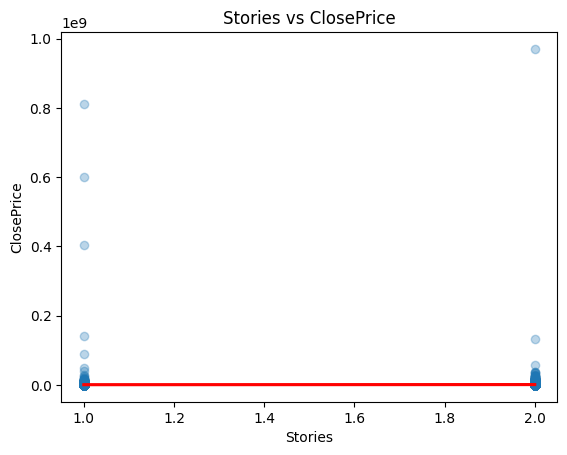

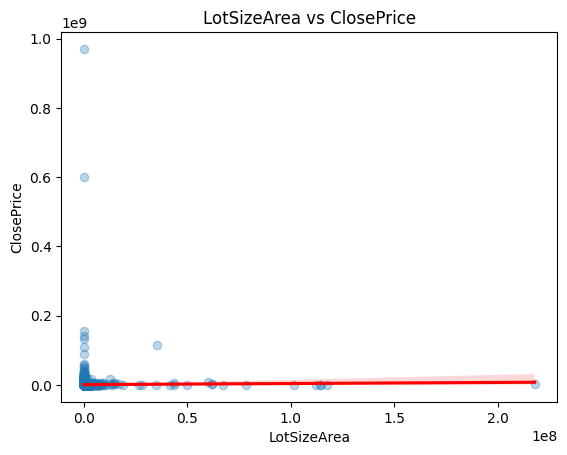

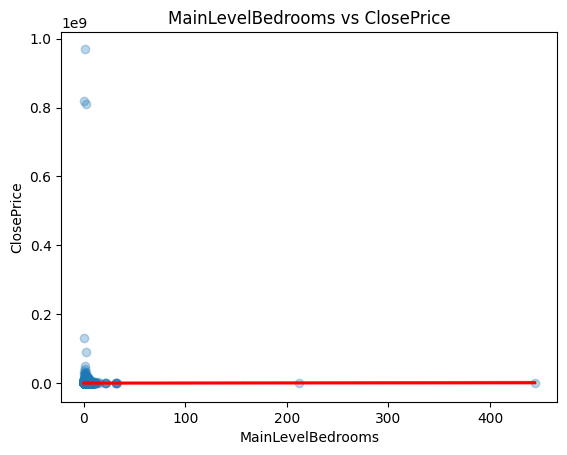

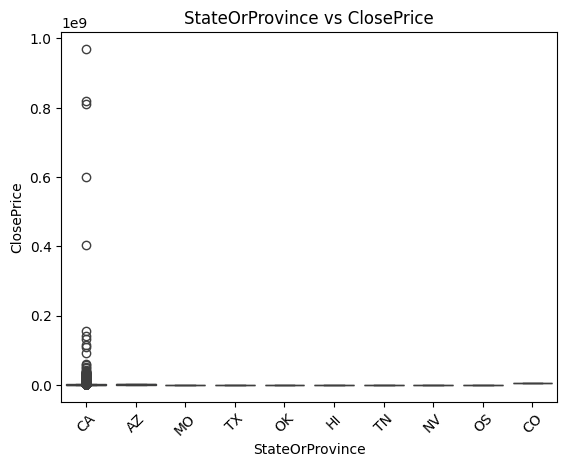

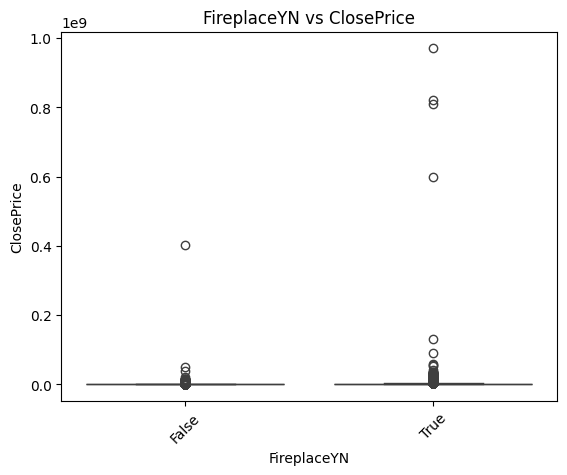

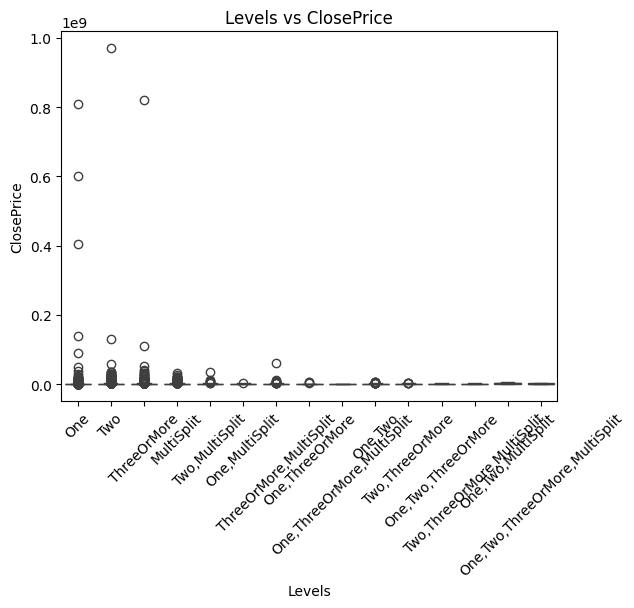

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ["Stories", "LotSizeArea", "MainLevelBedrooms"]:
    sns.regplot(x=df[col], y=df["ClosePrice"], scatter_kws={'alpha':0.3}, line_kws={'color': 'red'})
    plt.title(f"{col} vs ClosePrice")
    plt.show()

for col in ["StateOrProvince", "FireplaceYN", "Levels"]:
    sns.boxplot(x=df[col], y=df["ClosePrice"])
    plt.xticks(rotation=45)
    plt.title(f"{col} vs ClosePrice")
    plt.show()